In [7]:

import pandas as pd
import numpy as np
import os
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

PROCESSED_DIR = "../data/processed/"
MODELS_DIR = "../models/"

# Load
train_df = pd.read_csv(PROCESSED_DIR + "train_clean.csv")
test_df  = pd.read_csv(PROCESSED_DIR + "test_clean.csv")

y_train = train_df["Survived"].copy()
X_train = train_df.drop(columns=["Survived"])
X_test  = test_df.copy()

# Fix missing Fare in test (safety net)
X_test["Fare"] = X_test["Fare"].fillna(X_train["Fare"].median())

# Split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("X_tr :", X_tr.shape, "| X_val:", X_val.shape)
print("Missing — train:", X_train.isnull().sum().sum(), "| test:", X_test.isnull().sum().sum())

X_tr : (712, 11) | X_val: (179, 11)
Missing — train: 0 | test: 0


In [8]:

numeric_features = [
    "Pclass", "Age", "SibSp", "Parch", "Fare",
    "FamilySize", "IsAlone", "HasCabin"
]

categorical_features = [
    "Sex", "Embarked", "Title"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessor ready")
print("Numeric    :", numeric_features)
print("Categorical:", categorical_features)

Preprocessor ready
Numeric    : ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin']
Categorical: ['Sex', 'Embarked', 'Title']


In [9]:

lr_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr_param_grid = {
    "model__C":       [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver":  ["liblinear"]   # liblinear supports both l1 and l2
}

lr_grid = GridSearchCV(
    estimator=lr_pipe,
    param_grid=lr_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_tr, y_tr)

print("=== Logistic Regression — Best Params ===")
print(lr_grid.best_params_)
print(f"\nBest CV Accuracy: {lr_grid.best_score_:.4f}")

# Evaluate on validation
lr_val_pred = lr_grid.predict(X_val)
lr_val_acc  = accuracy_score(y_val, lr_val_pred)
print(f"Validation Accuracy: {lr_val_acc:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
=== Logistic Regression — Best Params ===
{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Best CV Accuracy: 0.8245
Validation Accuracy: 0.8045


c:\Users\bhatt\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [10]:

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_tr, y_tr)

print("=== Random Forest — Best Params ===")
print(rf_grid.best_params_)
print(f"\nBest CV Accuracy: {rf_grid.best_score_:.4f}")

# Evaluate on validation
rf_val_pred = rf_grid.predict(X_val)
rf_val_acc  = accuracy_score(y_val, rf_val_pred)
print(f"Validation Accuracy: {rf_val_acc:.4f}")

Fitting 5 folds for each of 135 candidates, totalling 675 fits
=== Random Forest — Best Params ===
{'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 300}

Best CV Accuracy: 0.8301
Validation Accuracy: 0.8212


In [11]:

from sklearn.model_selection import cross_val_score

candidates = {
    "LR_untuned": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "LR_tuned": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(C=0.1, penalty="l2",
                                     solver="liblinear",
                                     max_iter=1000, random_state=42))
    ]),
    "RF_untuned": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=100, max_depth=5,
                                          random_state=42, n_jobs=-1))
    ]),
    "RF_tuned": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=300, max_depth=5,
                                          min_samples_split=2, min_samples_leaf=4,
                                          random_state=42, n_jobs=-1))
    ]),
}

print("=== 5-Fold CV on FULL Training Data (891 rows) ===\n")
cv_summary = {}
for name, pipe in candidates.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy")
    cv_summary[name] = (scores.mean(), scores.std())
    print(f"{name:12s}  mean={scores.mean():.4f}  std={scores.std():.4f}")

# Rank by mean
print("\n=== Ranked by CV mean ===")
for name, (m, s) in sorted(cv_summary.items(), key=lambda x: -x[1][0]):
    print(f"  {name:12s}  {m:.4f}  (±{s:.4f})")

=== 5-Fold CV on FULL Training Data (891 rows) ===

LR_untuned    mean=0.8260  std=0.0271
LR_tuned      mean=0.8159  std=0.0237


c:\Users\bhatt\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\bhatt\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


RF_untuned    mean=0.8339  std=0.0228
RF_tuned      mean=0.8327  std=0.0241

=== Ranked by CV mean ===
  RF_untuned    0.8339  (±0.0228)
  RF_tuned      0.8327  (±0.0241)
  LR_untuned    0.8260  (±0.0271)
  LR_tuned      0.8159  (±0.0237)


=== Feature Importances (Random Forest) ===
     feature  importance
  Sex_female    0.194973
    Title_Mr    0.148648
    Sex_male    0.147726
        Fare    0.092740
      Pclass    0.090507
  FamilySize    0.052990
         Age    0.052753
    HasCabin    0.045507
  Title_Miss    0.040823
   Title_Mrs    0.035009
       SibSp    0.027814
Title_Master    0.020355
       Parch    0.012289
     IsAlone    0.011128
  Embarked_C    0.010564
  Embarked_S    0.007416
  Embarked_Q    0.004866
  Title_Rare    0.003892


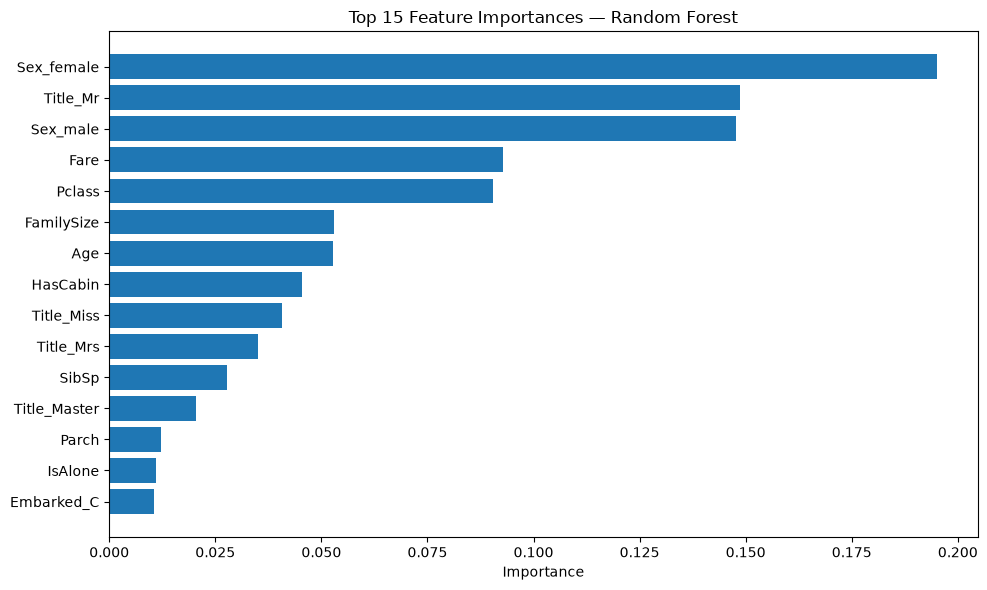

In [12]:

best_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, max_depth=5,
                                      random_state=42, n_jobs=-1))
])
best_pipe.fit(X_train, y_train)

# Get feature names AFTER preprocessing (one-hot expands columns)
ohe = best_pipe.named_steps["preprocessor"]\
               .named_transformers_["cat"]\
               .named_steps["onehot"]
encoded_cat_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = list(numeric_features) + list(encoded_cat_names)

# Get importances
importances = best_pipe.named_steps["model"].feature_importances_

# Sort
imp_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("=== Feature Importances (Random Forest) ===")
print(imp_df.to_string(index=False))

# Plot top 15
import matplotlib.pyplot as plt
top = imp_df.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

In [14]:

os.makedirs(MODELS_DIR, exist_ok=True)

# Retrain the winner on FULL training data (891 rows)
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ))
])

final_model.fit(X_train, y_train)

# Save
model_path = MODELS_DIR + "rf_final.joblib"
joblib.dump(final_model, model_path)

print("Saved model to:", model_path)
print("Model type:", type(final_model.named_steps["model"]).__name__)
print("Trained on:", X_train.shape[0], "rows")

Saved model to: ../models/rf_final.joblib
Model type: RandomForestClassifier
Trained on: 891 rows
